# Load Data into dataframe

In [2]:
import pandas as pd

df = pd.read_csv("LigaProTableTennis.csv")
df.head()

,Date,Player1,Player2,Sets_P1,Sets_P2,P1_G1,P2_G1,P1_G2,P2_G2,P1_G3,P2_G3,P1_G4,P2_G4,P1_G5,P2_G5,HomeWinner
0,2022-07-05 00:00:00,Hiblbauer J.,Kolacek I.,3.0,2,11,7,10,12,11,6,11.0,13.0,11.0,7.0,1.0
1,2022-07-05 00:00:00,Kleprlik K.,Pavliska M.,3.0,1,12,10,11,13,11,3,11.0,7.0,NaN,NaN,1.0
2,2022-07-05 00:15:00,Pikous M.,Pycha P.,3.0,1,11,9,9,11,11,7,11.0,6.0,NaN,NaN,1.0
3,2022-07-05 00:15:00,Schanel J.,Havel L.,2.0,3,5,11,11,9,5,11,11.0,8.0,8.0,11.0,0.0
4,2022-07-05 00:30:00,Pesek K.,Svoboda V.,3.0,0,11,3,11,9,11,3,NaN,NaN,NaN,NaN,1.0


# Results of Data Wrangler transformations

In [11]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(df):
    df = df.copy()

    # Convert score columns to numeric
    score_cols = ["P1_G1", "P2_G1", "P1_G2", "P2_G2", "P1_G3", "P2_G3", "P1_G4", "P2_G4", "P1_G5", "P2_G5"]
    for col in score_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop missing values
    df = df.dropna(subset=["HomeWinner", "P1_G1", "P2_G1", "P1_G2", "P2_G2", "Player1", "Player2", "Date"])

    # Convert target
    df["HomeWinner"] = df["HomeWinner"].astype(int)

    # Convert Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])

    # Feature engineering
    df["g1_margin"] = df["P1_G1"] - df["P2_G1"]
    df["g2_margin"] = df["P1_G2"] - df["P2_G2"]

    df["p1_games_won_first2"] = (
        (df["g1_margin"] > 0).astype(int) +
        (df["g2_margin"] > 0).astype(int)
    )

    # Extra features
    df["match_hour"] = df["Date"].dt.hour
    df["day_of_week"] = df["Date"].dt.dayofweek

    return df

df_clean = clean_data(df.copy())
df_clean.head()

,Date,Player1,Player2,Sets_P1,Sets_P2,P1_G1,P2_G1,P1_G2,P2_G2,P1_G3,...,P1_G4,P2_G4,P1_G5,P2_G5,HomeWinner,g1_margin,g2_margin,p1_games_won_first2,match_hour,day_of_week
0,2022-07-05 00:00:00,Hiblbauer J.,Kolacek I.,3.0,2,11,7,10,12,11,...,11.0,13.0,11.0,7.0,1,4,-2,1,0,1
1,2022-07-05 00:00:00,Kleprlik K.,Pavliska M.,3.0,1,12,10,11,13,11,...,11.0,7.0,NaN,NaN,1,2,-2,1,0,1
2,2022-07-05 00:15:00,Pikous M.,Pycha P.,3.0,1,11,9,9,11,11,...,11.0,6.0,NaN,NaN,1,2,-2,1,0,1
3,2022-07-05 00:15:00,Schanel J.,Havel L.,2.0,3,5,11,11,9,5,...,11.0,8.0,8.0,11.0,0,-6,2,1,0,1
4,2022-07-05 00:30:00,Pesek K.,Svoboda V.,3.0,0,11,3,11,9,11,...,NaN,NaN,NaN,NaN,1,8,2,2,0,1


# Visualization 1: Distribution of the target variable

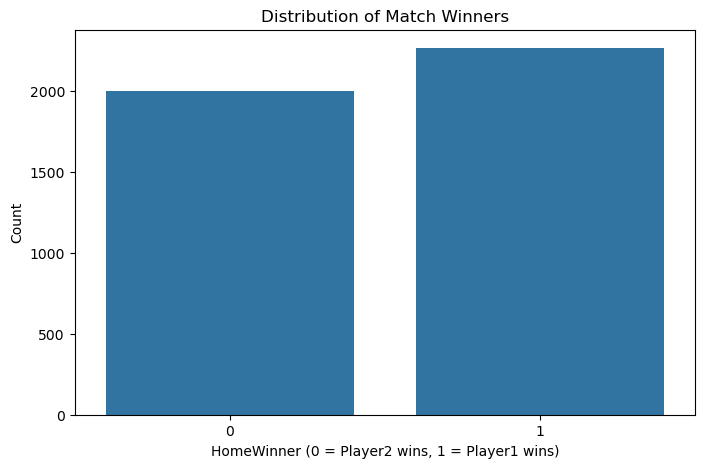

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="HomeWinner")
plt.title("Distribution of Match Winners")
plt.xlabel("HomeWinner (0 = Player2 wins, 1 = Player1 wins)")
plt.ylabel("Count")
plt.show()

# Visualization 2: Game 1 margin compared with final match winner

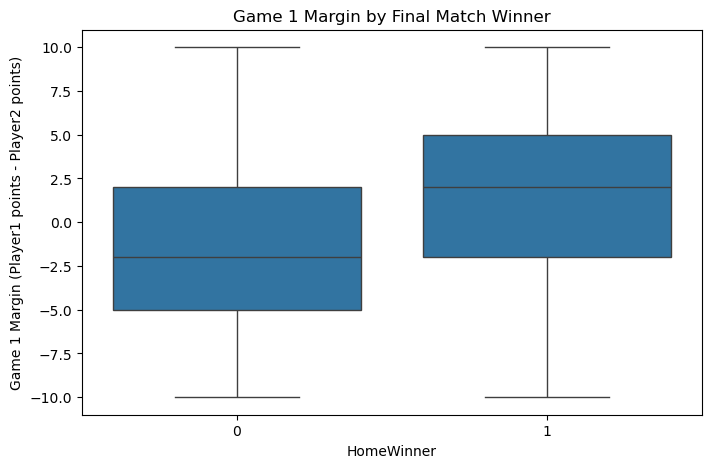

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="HomeWinner", y="g1_margin")
plt.title("Game 1 Margin by Final Match Winner")
plt.xlabel("HomeWinner")
plt.ylabel("Game 1 Margin (Player1 points - Player2 points)")
plt.show()

# Visualization 3: Number of first two games won by Player1 versus final match winner

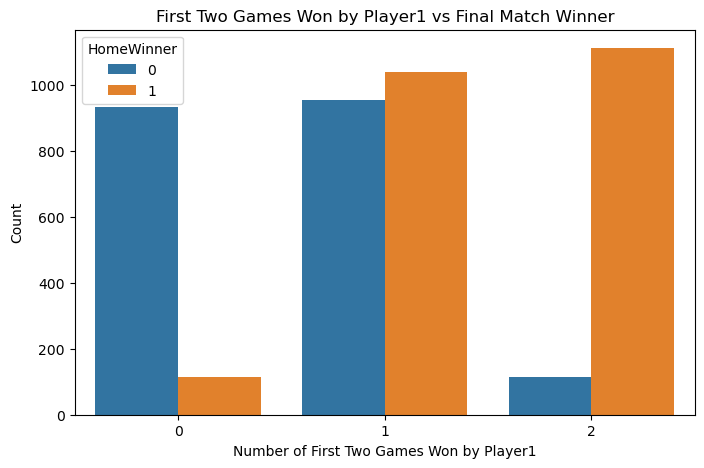

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="p1_games_won_first2", hue="HomeWinner")
plt.title("First Two Games Won by Player1 vs Final Match Winner")
plt.xlabel("Number of First Two Games Won by Player1")
plt.ylabel("Count")
plt.show()

# Correlation matrix for engineered numeric predictors

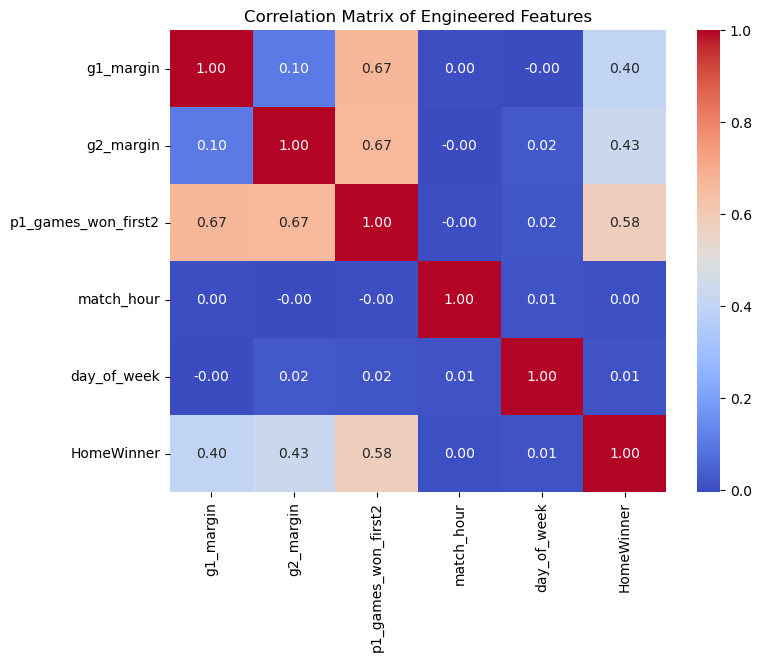

In [15]:
numeric_cols = ["g1_margin", "g2_margin", "p1_games_won_first2", "match_hour", "day_of_week", "HomeWinner"]

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Engineered Features")
plt.show()

# Logistic Regression Baseline Model: Predicting HomeWinner using first two game margins

Baseline Accuracy: 0.7532163742690059
Baseline ROC AUC: 0.836748986564426

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.69      0.72       401
           1       0.75      0.81      0.78       454

    accuracy                           0.75       855
   macro avg       0.75      0.75      0.75       855
weighted avg       0.75      0.75      0.75       855



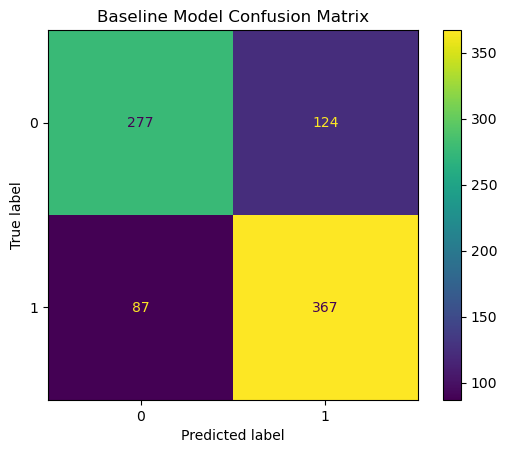

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score

X = df_clean[["g1_margin", "g2_margin"]]
y = df_clean["HomeWinner"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline ROC AUC:", baseline_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_base))

ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test)
plt.title("Baseline Model Confusion Matrix")
plt.show()

# Revised Logistic Regression Model: Add player identity and first-two-game win count

Improved Accuracy: 0.7695906432748538
Improved ROC AUC: 0.840377030990805

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.72      0.75       401
           1       0.77      0.81      0.79       454

    accuracy                           0.77       855
   macro avg       0.77      0.77      0.77       855
weighted avg       0.77      0.77      0.77       855



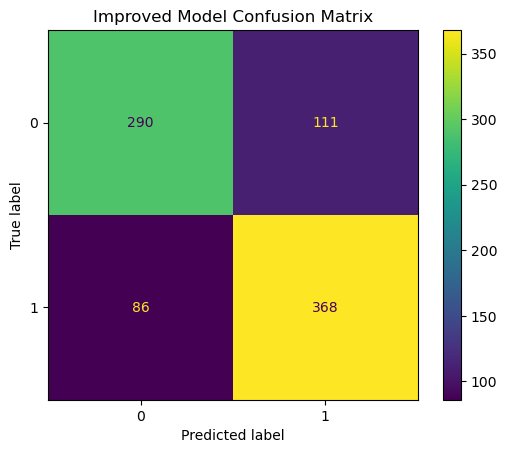

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X2 = df_clean[["Player1", "Player2", "g1_margin", "g2_margin", "p1_games_won_first2"]]
y2 = df_clean["HomeWinner"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

categorical_features = ["Player1", "Player2"]
numeric_features = ["g1_margin", "g2_margin", "p1_games_won_first2"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

improved_model = Pipeline([
    ("preprocessor", preprocessor),
    ("logreg", LogisticRegression(max_iter=1000))
])

improved_model.fit(X2_train, y2_train)

y_pred_improved = improved_model.predict(X2_test)
y_prob_improved = improved_model.predict_proba(X2_test)[:, 1]

improved_accuracy = accuracy_score(y2_test, y_pred_improved)
improved_auc = roc_auc_score(y2_test, y_prob_improved)

print("Improved Accuracy:", improved_accuracy)
print("Improved ROC AUC:", improved_auc)
print("\nClassification Report:\n")
print(classification_report(y2_test, y_pred_improved))

ConfusionMatrixDisplay.from_estimator(improved_model, X2_test, y2_test)
plt.title("Improved Model Confusion Matrix")
plt.show()

# Revised Logistic Regression Model 2: Adding match timing features

Revision 2 Accuracy: 0.7707602339181286
Revision 2 ROC AUC: 0.8403056236061828

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.72      0.75       401
           1       0.77      0.81      0.79       454

    accuracy                           0.77       855
   macro avg       0.77      0.77      0.77       855
weighted avg       0.77      0.77      0.77       855



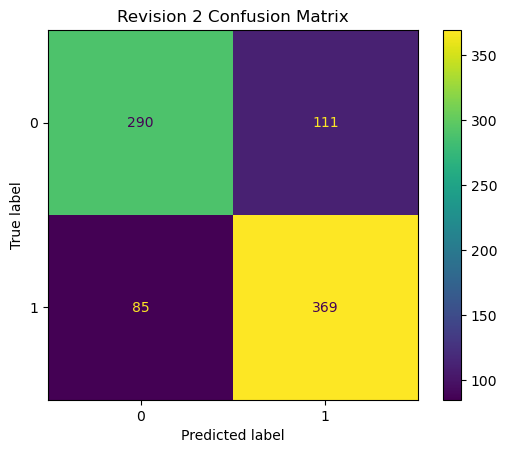

In [18]:
X3 = df_clean[[
    "Player1",
    "Player2",
    "g1_margin",
    "g2_margin",
    "p1_games_won_first2",
    "match_hour",
    "day_of_week"
]]

y3 = df_clean["HomeWinner"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

categorical_features_3 = ["Player1", "Player2"]
numeric_features_3 = ["g1_margin", "g2_margin", "p1_games_won_first2", "match_hour", "day_of_week"]

preprocessor3 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_3),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features_3)
])

model_revision_2 = Pipeline([
    ("preprocessor", preprocessor3),
    ("logreg", LogisticRegression(max_iter=1000))
])

model_revision_2.fit(X3_train, y3_train)

y_pred_rev2 = model_revision_2.predict(X3_test)
y_prob_rev2 = model_revision_2.predict_proba(X3_test)[:, 1]

revision2_accuracy = accuracy_score(y3_test, y_pred_rev2)
revision2_auc = roc_auc_score(y3_test, y_prob_rev2)

print("Revision 2 Accuracy:", revision2_accuracy)
print("Revision 2 ROC AUC:", revision2_auc)
print("\nClassification Report:\n")
print(classification_report(y3_test, y_pred_rev2))

ConfusionMatrixDisplay.from_estimator(model_revision_2, X3_test, y3_test)
plt.title("Revision 2 Confusion Matrix")
plt.show()

# Final Summary

From working with this dataset, I found that how a player performs in the first two games has a big impact on the final outcome of the match. If Player1 wins both of the first two games or has strong score margins early on, they are much more likely to win the match overall.

I also noticed that adding player names into the model improved the predictions, which suggests that some players are just consistently stronger than others. So it’s not just early momentum that matters, but also who is playing.

Overall, I learned that even using just the first part of a match, you can still make pretty solid predictions about the final result.

# What did I predict? 

I predicted whether Player1 would win the match.

# How good was the prediction?

The revised model worked better than the first one, so adding more features like player names actually helped improve the predictions.

# What could this prediction be used for?

This type of prediction could be useful for things like live match analysis, sports commentary, or tracking player performance.